# interpret

> fastai's `Interpretation` for typed decisions (the worst cases, confusion, calibration and coverage), and attributions in the style of transformers-interpret: how much each token, pixel and residue moved each option's probability, by integrated gradients through a sysone model or by occlusion through any backend.

In [ ]:
#| default_exp interpret

In [ ]:
#| export
import base64, html, io, json, math, re, textwrap
from contextlib import contextmanager
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch
from fastcore.basics import patch

from sysone.core import *
from sysone.template import *
from sysone.models import StreamEncoder, SideEncoder
from sysone.losses import coverage_curve, ece_score, row_thresholds
from sysone.metrics import *
from sysone.learner import Learner
from sysone.inference import Decider

In [ ]:
#| hide
from fastcore.test import test_eq, test_close, test_fail
import logging, tempfile
from pathlib import Path
logging.getLogger("transformers").setLevel(logging.ERROR)
import datasets, transformers; datasets.disable_progress_bars(); transformers.utils.logging.disable_progress_bar()
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
from transformers.trainer_callback import PrinterCallback, ProgressCallback
PrinterCallback.on_log = ProgressCallback.on_log = lambda *a, **k: None          # the Trainer's log lines stay out of these pages
set_matplotlib_formats("png")
plt.rcParams.update({"figure.dpi": 90, "axes.spines.top": False, "axes.spines.right": False, "font.size": 9,
                     "axes.titlesize": 9, "legend.fontsize": 8, "legend.frameon": False})

A trained decider raises three questions, and sysone answers each with its own tools:

- **How good is it?** The [metrics](04a_metrics.ipynb): accuracy and macro-F1, calibration, the error of a level, what acting only on sure answers buys.
- **Where is it wrong?** `Interpretation`, fastai's: the decisions with the largest losses, the confusions between options, how its confidence compares with how often it is right.
- **Why did it answer that?** Attributions, in the style of [transformers-interpret](https://github.com/cdpierse/transformers-interpret): for each option, how much every token of the row, every pixel of its image and every residue of its protein moved that option's probability.

```{mermaid}
flowchart LR
    L["a Learner and a split"] -->|Interpretation.from_learner| I[Interpretation]
    D["any backend and records with gold"] -->|Interpretation.from_decider| I
    I --> W["top_losses · plot_top_losses<br/>confusion_matrix · most_confused<br/>classification_report"]
    I --> C["plot_calibration · plot_coverage · metrics"]
    I -->|"explain(i)"| A[Attribution]
    M["a sysone model:<br/>learn.explain · decider.explain"] -->|"integrated gradients,<br/>gradient × input, saliency"| A
    B["any backend"] -->|occlusion| A
    A --> V["a row per option: words coloured,<br/>images and residues drawn"]
```

Importing `sysone.interpret` adds `explain` to learners and deciders, as importing [`sysone.cache`](07_cache.ipynb) adds `fit_linear`. Below, everything runs on the tiny random fixtures, so the numbers mean nothing and only the mechanics matter. The [interpretation tutorial](tutorials/interpretation.ipynb) runs it on real models: the text application on emotions in tweets, the multimodal application on digits and hot dogs, and the protein application on where proteins live in the cell.

A small text model to look at, trained on the twenty typed-decisions fixtures, with an act head:

In [ ]:
from sysone.data import TypedDecisions
from sysone.learner import decision_learner

In [ ]:
recs = [json.loads(l) for l in Path("fixtures/typed_decisions_tiny.jsonl").read_text().splitlines()]
data = TypedDecisions.from_records(recs, valid=0.25, calib=0.2)
torch.manual_seed(0)
learn = decision_learner(data, "fixtures/tiny-modernbert", train="head", preset="cpu", act=True, loss="soft_ce", calibrate_after_fit=False)
learn.fit(3, lr=3e-3)
learn.calibrate(min_rows=2, act_accuracy=0.5);

## Interpretation

`Interpretation` holds a split's decisions as a [`Preds`](04a_metrics.ipynb#preds), with the record each one came from. `from_learner` reads a learner's split through `get_preds`, from its feature cache when it has one. `from_decider` asks any backend that answers in the Jev schema: a sysone `Decider`, a zero-shot decider, a GLiNER2 decider or Laya's runtime. The verbs are fastai's, with typed decisions in mind:

- `top_losses` and `plot_top_losses` find the decisions with the largest cross-entropy against the gold: the confident mistakes first.
- `confusion_matrix`, `most_confused` and `classification_report` work on one question at a time, since a question's options are its classes.
- `plot_calibration` draws the reliability diagram, and `plot_coverage` the accuracy of the answers acted on, surest first, with the act rule's point on it.
- `metrics` makes a table of any metrics, over all the decisions or per question type, question id or record field.
- `explain(i)` attributes decision `i` (below).

In [ ]:
#| export
class Interpretation:
    "fastai's `Interpretation` for typed decisions: a split's decisions (or a backend's answers to records) beside their gold, with the records they came from"
    def __init__(self, preds:Preds, records:dict, decider=None, builder=None, act_threshold=None, act_score=None):
        self.preds, self.records, self.decider, self.builder = preds, records, decider, builder
        self.act_threshold, self.act_score = act_threshold, act_score

    def __repr__(self): return f"Interpretation({self.preds!r} · {len(self.records)} records)"

    @classmethod
    def from_learner(cls, learn:Learner, split:str="valid"):
        "The decisions of a learner's split, read through `get_preds` (from its feature cache, when it has one)"
        p = learn.get_preds(split)
        cases = learn.data.cases[split]
        recs = {int(i): load_record(cases[int(i)]) for i in sorted(set(p.case_idx.tolist()))}
        return cls(p, recs, decider=learn.decider(), builder=learn.data.builder, act_threshold=learn.act_threshold, act_score=learn.act_score)

    @classmethod
    def from_decider(cls, decider, records, batch_size:int=16):
        "The decisions any backend (anything with `predict`) makes on records with gold"
        recs = [load_record(r) for r in records]
        answers = _answer_all(decider, recs, batch_size)
        return cls(Preds.from_answers(recs, answers), dict(enumerate(recs)), decider=decider, builder=getattr(decider, "builder", None),
                   act_threshold=getattr(decider, "act_threshold", None), act_score=getattr(decider, "act_score", None))

def _answer_all(model, recs, batch_size):
    "Every record's answers: batched when the backend can and every record asks the same questions"
    same = len({json.dumps(r["questions"], sort_keys=True) for r in recs}) == 1
    if same and hasattr(model, "predict_batch"): return _predict_many(model, [r["state"] for r in recs], recs[0]["questions"], batch_size)
    return [model.predict(r["state"], r["questions"]) for r in recs]

def _predict_many(model, states, questions, batch_size):
    if not hasattr(model, "predict_batch"): return [model.predict(s, questions) for s in states]
    out = []
    for i in range(0, len(states), batch_size): out += model.predict_batch(states[i:i + batch_size], questions)
    return out

In [ ]:
interp = Interpretation.from_learner(learn, "valid")
interp

Interpretation(Preds(25 rows: 7 choice, 10 score, 8 noul · 0 unanswerable · calibrated) · 5 records)

### The worst decisions

A decision's loss is the cross-entropy of its probabilities against its gold distribution, the same number the validation loss averages. A row with no right option has none. `top_losses` returns the losses and their rows, largest first as in fastai, and with `items=True` each row's record and question id too:

In [ ]:
#| export
@patch(as_prop=True)
def losses(self:Interpretation) -> np.ndarray:
    "Each decision's cross-entropy against its gold (NaN where none of its options is right)"
    p = self.preds
    return np.where(p.ok, -(p.targets * np.log(np.clip(p.probs, 1e-12, 1))).sum(1), np.nan)

@patch
def top_losses(self:Interpretation, k:int|None=None, largest:bool=True, items:bool=False) -> tuple:
    "The `k` largest (or smallest) losses and their rows, and with `items` each row's record and question id"
    l = self.losses; idx = np.flatnonzero(~np.isnan(l))
    idx = idx[np.argsort(-l[idx] if largest else l[idx], kind="stable")][:k]
    return (l[idx], idx) + ((self.items(idx),) if items else ())

@patch
def items(self:Interpretation, idxs) -> list:
    "The record and the question id of each row"
    return [(self.records[int(self.preds.case_idx[i])], str(self.preds.qids[i])) for i in idxs]

In [ ]:
l, idx = interp.top_losses(3)
test_eq(len(idx), 3); assert (np.diff(l) <= 0).all()
test_close(np.nanmean(interp.losses), log_loss(interp.preds))
(rec0, qid0), = interp.items(idx[:1])
l, idx, qid0

(array([1.60944678, 1.60943839, 1.60939457]), array([22,  5,  6]), 'severity')

`show_results` draws a card per decision: the input as the model saw it (the text, the image, or the protein's residues), the question, and the likeliest options beside the gold, the answer in dark blue. `record_view` decides how to show an input. It looks at the builder's transforms first (an `Image` or a `Stream` transform names the state's image or sequence), and otherwise at the state itself. `plot_top_losses` shows the cards of the largest losses. Like the other `plot_` methods, it returns the figure, which a notebook displays:

In [ ]:
#| export
_INK, _GRAY, _BLUE, _LIGHT, _TRACK, _CARD = "#111111", "#6b6b6b", "#3b3ff5", "#9a9df7", "#d9d9de", "#f4f4f6"
_GREEN, _RED = (22, 163, 74), (220, 38, 38)

def _image_like(v) -> bool:
    "Whether a state value is an image: a PIL image, or a path to an image file"
    return hasattr(v, "convert") or (isinstance(v, (str, Path)) and re.search(r"\.(png|jpe?g|webp|bmp|gif)$", str(v), re.I) is not None)

def record_view(record:dict, builder=None) -> tuple:
    "How to show a record's input: ('image', a PIL image), ('sequence', its letters) or ('text', the state as text)"
    st = record["state"]
    if isinstance(st, str) and st[:1] in "{[":
        try: st = json.loads(st)
        except json.JSONDecodeError: pass
    for t in (builder.tfms if builder is not None else []):
        if isinstance(st, dict) and isinstance(t, Image) and st.get(t.key) is not None: return "image", load_image(st[t.key])
        if isinstance(st, dict) and isinstance(t, Stream) and st.get(t.key) is not None: return "sequence", str(st[t.key])
    if isinstance(st, dict):
        for v in st.values():
            if _image_like(v): return "image", load_image(v)
        if isinstance(st.get("sequence"), str): return "sequence", st["sequence"]
    return "text", render_state(st)

def _draw_view(ax, view, width:int=31, lines:int=12, size:float=7.5):
    "An input in a card's panel: an image, a protein's first residues, or wrapped text"
    kind, v = view
    ax.axis("off")
    if kind == "image":
        a = np.asarray(v); ax.imshow(a, interpolation="nearest" if max(a.shape[:2]) < 96 else "antialiased")
    else:
        wrapped = [v[i:i + 30] for i in range(0, len(v), 30)] if kind == "sequence" else textwrap.wrap(v, width)
        more = f"… {len(v)} residues" if kind == "sequence" else "…"
        text = "\n".join(wrapped[:lines] + ([more] if len(wrapped) > lines else [f"{len(v)} residues"] if kind == "sequence" else []))
        ax.text(0, 1, text, va="top", ha="left", fontsize=size, family="monospace" if kind == "sequence" else None,
                transform=ax.transAxes, clip_on=True)

def _bars(ax, keys, probs, gold, pred, top:int=4):
    "The likeliest options as bars, the answer dark, the gold ticked (shown even when it is not among them)"
    from matplotlib.patches import Rectangle
    order = list(np.argsort(-probs))[:top]
    if gold >= 0 and gold not in order: order[-1] = gold
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
    for i, o in enumerate(order):
        y = 1 - (i + 1) / (top + 0.3)
        ax.add_patch(Rectangle((0, y), 1, 0.08, color=_TRACK, lw=0))
        ax.add_patch(Rectangle((0, y), max(float(probs[o]), 0.004), 0.08, color=_BLUE if o == pred else _LIGHT, lw=0))
        ax.text(0, y + 0.1, f"{'✓' if o == gold else '✕'} {keys[o]}  {probs[o]:.0%}", fontsize=8, va="bottom",
                color=_INK if o in (gold, pred) else _GRAY, weight="bold" if o == gold else "normal")

@patch
def show_results(self:Interpretation, idxs, ncols:int=3):
    "Cards for some decisions: the input, the question, and the likeliest options beside the gold"
    import matplotlib.pyplot as plt
    idxs, p = list(idxs), self.preds
    nrows = max(1, -(-len(idxs) // ncols))
    fig = plt.figure(figsize=(4.4 * ncols, 2.5 * nrows))
    sfs = np.atleast_1d(fig.subfigures(nrows, ncols, wspace=0.03, hspace=0.06)).ravel()
    for sf, i in zip(sfs, idxs):
        (rec, qid), = self.items([i])
        keys, k = p.option_keys[i], int(p.k[i])
        q, loss, gold, pred = as_questions(rec["questions"])[qid], self.losses[i], int(p.labels[i]), int(p.pred[i])
        sf.set_facecolor(_CARD)
        sf.text(0.03, 0.95, f"{qid}: {textwrap.shorten(q.instructions, 62)}", fontsize=8, color=_GRAY, va="top")
        sf.text(0.03, 0.86, f"gold {keys[gold] if gold >= 0 else '(none of these)'} · answer {keys[pred]}" + ("" if np.isnan(loss) else f" · loss {loss:.2f}"),
                fontsize=9, weight="bold", color=_INK, va="top")
        _draw_view(sf.add_axes([0.03, 0.04, 0.42, 0.7]), record_view(rec, self.builder))
        _bars(sf.add_axes([0.5, 0.04, 0.47, 0.7]), keys, p.probs[i, :k], gold, pred)
    for sf in sfs[len(idxs):]: sf.set_facecolor("white")
    plt.close(fig)
    return fig

@patch
def plot_top_losses(self:Interpretation, k:int=6, largest:bool=True, ncols:int=3):
    "Cards for the `k` decisions with the largest (or smallest) losses"
    return self.show_results(self.top_losses(k, largest)[1], ncols)

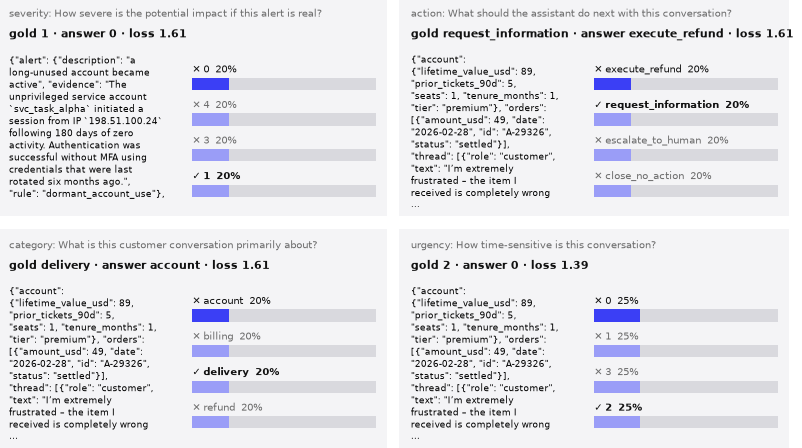

In [ ]:
interp.plot_top_losses(4, ncols=2)

### Confusions

A question's options are its classes, so the confusion matrix, `most_confused` and `classification_report` take the question id (`qid`; with one question in the split, it is that one). Classes are the options' keys, gathered over the question's rows in the order they first appear. In typed-decisions, the same question id can offer different options in different cases, and then its matrix holds every option it offered.

In [ ]:
#| export
@patch
def _question(self:Interpretation, qid=None) -> tuple:
    "A question's id, its answerable rows, and every option key its rows offer, in the order they first appear"
    p = self.preds; qids = sorted(set(p.qids.tolist()))
    if qid is None:
        if len(qids) != 1: raise ValueError(f"the decisions come from {len(qids)} questions; name one with qid= ({qids[:8]})")
        qid = qids[0]
    if qid not in qids: raise ValueError(f"no decisions on question {qid!r}; the split has {qids[:8]}")
    rows = np.flatnonzero((p.qids == qid) & p.ok)
    keys = list(dict.fromkeys(k for i in rows for k in p.option_keys[i]))
    return qid, rows, keys

@patch
def confusion_matrix(self:Interpretation, qid=None, normalize:bool=False):
    "Gold labels (rows) against answers (columns) for one question, as counts or, normalised, as shares of each gold label"
    import pandas as pd
    qid, rows, keys = self._question(qid)
    p, M = self.preds, np.zeros((len(keys), len(keys)))
    for i in rows: M[keys.index(p.option_keys[i][p.labels[i]]), keys.index(p.option_keys[i][p.pred[i]])] += 1
    if normalize: M = M / np.clip(M.sum(1, keepdims=True), 1, None)
    return pd.DataFrame(M if normalize else M.astype(int), index=pd.Index(keys, name="gold"), columns=pd.Index(keys, name="answer"))

@patch
def plot_confusion_matrix(self:Interpretation, qid=None, normalize:bool=False, title:str|None=None, cmap:str="Blues", norm_dec:int=2,
                          plot_txt:bool=True):
    "One question's confusion matrix, drawn"
    import matplotlib.pyplot as plt
    cm = self.confusion_matrix(qid, normalize); M, keys = cm.values, list(cm.index)
    fig, ax = plt.subplots(figsize=(1.2 + 0.55 * len(keys), 1.0 + 0.5 * len(keys)))
    ax.imshow(M, cmap=cmap, vmin=0, vmax=M.max() if M.max() > 0 else 1)
    if plot_txt:
        for (r, c), v in np.ndenumerate(M):
            if v: ax.text(c, r, f"{v:.{norm_dec}f}" if normalize else int(v), ha="center", va="center", fontsize=8, color="white" if v > M.max() / 2 else _INK)
    ax.set_xticks(range(len(keys)), keys, rotation=45, ha="right", fontsize=8); ax.set_yticks(range(len(keys)), keys, fontsize=8)
    ax.set_xlabel("answer"); ax.set_ylabel("gold")
    counts = self.confusion_matrix(qid)
    ax.set_title(title or f"{self._question(qid)[0]}: accuracy {np.trace(counts.values) / max(counts.values.sum(), 1):.2f}" + (" (each gold label's shares)" if normalize else ""))
    for s in ("top", "right"): ax.spines[s].set_visible(True)
    fig.tight_layout(); plt.close(fig)
    return fig

@patch
def most_confused(self:Interpretation, qid=None, min_val:int=1) -> list:
    "The off-diagonal cells of one question's confusion matrix, largest first, as (gold, answer, count)"
    cm = self.confusion_matrix(qid)
    out = [(g, a, int(cm.loc[g, a])) for g in cm.index for a in cm.columns if g != a and cm.loc[g, a] >= min_val]
    return sorted(out, key=lambda x: -x[2])

@patch
def classification_report(self:Interpretation, qid=None):
    "Precision, recall, F1 and support of each of a question's options, then their macro and support-weighted averages"
    import pandas as pd
    cm = self.confusion_matrix(qid); C = cm.values.astype(float)
    tp, fp, fn, sup = np.diag(C), C.sum(0) - np.diag(C), C.sum(1) - np.diag(C), C.sum(1)
    pr, rc, f1 = tp / np.maximum(tp + fp, 1), tp / np.maximum(tp + fn, 1), 2 * tp / np.maximum(2 * tp + fp + fn, 1)
    df = pd.DataFrame({"precision": pr, "recall": rc, "f1": f1, "support": sup.astype(int)}, index=cm.index)
    has = sup > 0
    df.loc["macro avg"] = [pr[has].mean(), rc[has].mean(), f1[has].mean(), sup.sum()]
    df.loc["weighted avg"] = [(v * sup).sum() / max(sup.sum(), 1) for v in (pr, rc, f1)] + [sup.sum()]
    return df.astype({"support": int})

In [ ]:
cm = interp.confusion_matrix("urgency")
test_eq(cm.values.sum(), int(((interp.preds.qids == "urgency") & interp.preds.ok).sum()))
rep = interp.classification_report("urgency")
test_close(rep.loc["macro avg", "f1"], f1_score(interp.preds.select(interp.preds.qids == "urgency")))
test_fail(lambda: interp.confusion_matrix(), contains="name one with qid=")
cm, interp.most_confused("urgency"), rep.round(2)

(answer  0  1  2  3
 gold              
 0       0  1  0  0
 1       1  0  0  1
 2       1  0  0  0
 3       1  0  0  0,
 [('0', '1', 1), ('1', '0', 1), ('1', '3', 1), ('2', '0', 1), ('3', '0', 1)],
               precision  recall   f1  support
 gold                                         
 0                   0.0     0.0  0.0        1
 1                   0.0     0.0  0.0        2
 2                   0.0     0.0  0.0        1
 3                   0.0     0.0  0.0        1
 macro avg           0.0     0.0  0.0        5
 weighted avg        0.0     0.0  0.0        5)

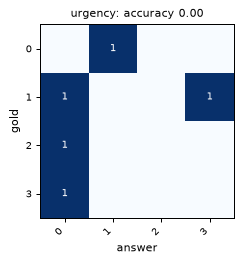

In [ ]:
interp.plot_confusion_matrix("urgency")

### Calibration and coverage

The reliability diagram sorts decisions into bins by the probability of their answer, and draws, per bin, how often they were right. A calibrated model's bars meet the diagonal, and the histogram under it says how many answers each bin holds. With `by="qtype"`, there is a panel per question type, since each type has its own temperatures. `plot_coverage` acts on the surest answers first and draws their accuracy against the share acted on. The point on it is the act rule the learner fitted, which acts where p(act), or the calibrated confidence, reaches its bucket's threshold (see [losses](04_losses.ipynb#the-act-head)). Acting on an unanswerable row counts as a mistake.

In [ ]:
#| export
@patch
def plot_calibration(self:Interpretation, bins:int=10, by:str|None=None):
    "A reliability diagram: how often answers are right against how sure they are, bin by bin, over the answers each bin holds (a panel per question type with `by='qtype'`)"
    import matplotlib.pyplot as plt
    p = self.preds
    groups = [("all questions", p.ok)] if by is None else [(QTYPE_NAMES[t], p.ok & (p.qtypes == t)) for t in sorted(set(p.qtypes[p.ok].tolist()))]
    fig, axs = plt.subplots(2, len(groups), figsize=(3.4 * len(groups), 3.6), squeeze=False, gridspec_kw={"height_ratios": [3, 1]}, sharex=True)
    edges = np.linspace(0, 1, bins + 1)
    for (name, m), ax, hx in zip(groups, axs[0], axs[1]):
        c, r = p.conf[m], p.correct[m].astype(float)
        b = np.clip(np.digitize(c, edges[1:-1]), 0, bins - 1)
        acc = np.array([r[b == i].mean() if (b == i).any() else np.nan for i in range(bins)])
        ax.bar(edges[:-1], acc, width=1 / bins, align="edge", color=_BLUE, alpha=0.8, edgecolor="white", label="share right")
        ax.plot([0, 1], [0, 1], "--", color=_GRAY, lw=1, label="calibrated")
        ax.set_title(f"{name}: ECE {ece_score(c, r, bins):.3f}"); ax.set_ylim(0, 1)
        hx.hist(c, bins=edges, color=_LIGHT); hx.set_xlabel("confidence (the answer's probability)")
    axs[0, 0].set_ylabel("share right"); axs[1, 0].set_ylabel("answers"); axs[0, 0].legend(loc="upper left")
    fig.tight_layout(); plt.close(fig)
    return fig

@patch
def plot_coverage(self:Interpretation, score:str|None=None):
    "Accuracy on the answers acted on, surest first, against the share acted on, with the act rule's point when there is one"
    import matplotlib.pyplot as plt
    p = self.preds
    score = score or ("act" if self.act_score == "head" and "act" in p else "confidence")
    s, cv = selection_scores(p, score), coverage_curve(selection_scores(p, score), p.right)
    fig, ax = plt.subplots(figsize=(5, 2.9))
    ax.plot(cv["coverage"], cv["accuracy"], color=_BLUE, lw=1.5, label=f"acting on the surest first ({score})")
    ax.axhline(p.right.mean(), color=_GRAY, ls="--", lw=1, label=f"acting on everything: {p.right.mean():.2f}")
    if self.act_threshold is not None and (score == "act") == (self.act_score == "head"):
        act = s >= row_thresholds(self.act_threshold, p.qtypes, p.k)
        ax.plot([act.mean()], [p.right[act].mean() if act.any() else np.nan], "o", color="C3", label=f"the act rule: acts on {act.mean():.0%}")
    ax.set(xlabel="coverage (share of decisions acted on)", ylabel="accuracy when acting", ylim=(0, 1.02))
    ax.legend(loc="lower left"); fig.tight_layout(); plt.close(fig)
    return fig

@patch
def metrics(self:Interpretation, metrics=None, by=None):
    "A table of metrics over every decision, and per group with `by`: 'qtype', 'qid', or a function of the record"
    if callable(by): by = [str(by(self.records[int(c)])) for c in self.preds.case_idx]
    return metrics_table(self.preds, metrics, by)

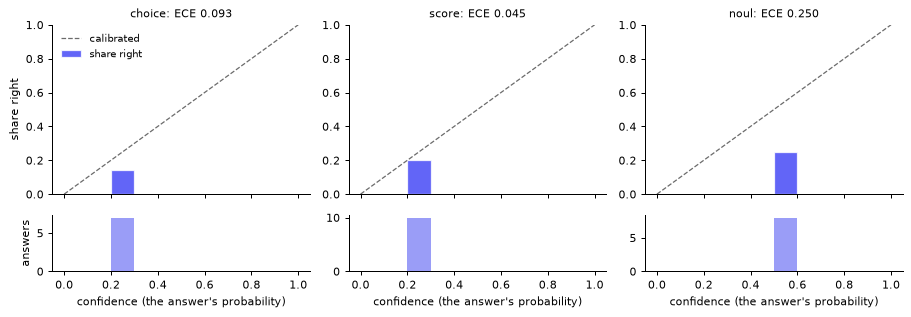

In [ ]:
interp.plot_calibration(by="qtype")

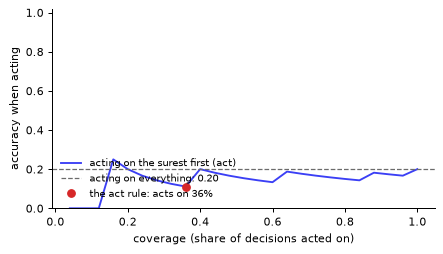

In [ ]:
interp.plot_coverage()

In [ ]:
interp.metrics([accuracy, F1Score(), log_loss, brier_score, ece, aurc], by=lambda r: r["workflow"]).round(3)

,accuracy,f1_score,log_loss,brier_score,ece,aurc,rows
all,0.2,0.148,1.191,0.260,0.124,0.722,25
agent_trace_observability,0.2,0.200,1.248,0.261,0.100,0.843,5
customer_service,0.0,0.000,1.337,0.316,0.280,1.000,5
invoice_processing,0.4,0.267,1.109,0.328,0.050,0.579,10
security_incidents,0.0,0.000,1.154,0.066,0.340,1.000,5


`from_decider` scores any backend the same way, from its answers. Here it is the learner's own `Decider` over all twenty fixture records, and the shared metrics agree with [`evaluate`](09_evaluate.ipynb):

In [ ]:
from sysone.evaluate import evaluate

In [ ]:
dec = learn.decider()
ivd = Interpretation.from_decider(dec, recs)
ev = evaluate(dec, recs)
test_close(accuracy(ivd.preds), ev["accuracy"]); test_close(f1_score(ivd.preds), ev["macro_f1"])
ivd

Interpretation(Preds(100 rows: 30 choice, 40 score, 30 noul · 0 unanswerable · T = 1) · 20 records)

## Attributions

An attribution answers *why this option?* for one decision. For each option it explains, it gives every unit of the input a number: a token of the row, a pixel of its image, a residue of its protein. A positive number means the unit raised that option's log-odds, and a negative one that it lowered them. sysone computes attributions two ways.

- **Through the model**, with its gradients: integrated gradients, gradient × input, and saliency. These need a sysone model (a `Learner`'s, or a `Decider`'s), since they run backwards through it, and they score every unit of every input at once.
- **Through any backend**, by occlusion: hide one piece of the state at a time, ask again, and see how far each option's probability falls. It needs nothing but `predict`, so it works for zero-shot deciders, GLiNER2 and Laya's runtime too, and its numbers are the model's real answers on the changed inputs.

### What a row is made of

A decision row is a template's text, `[CLS] choice question: … [SEP] [MASK] option 1 [MASK] option 2 … [SEP] state [SEP]`, plus an image or a side stream when the encoder reads one. To show an attribution, the tokens need their text, and each needs a role. `token_texts` decodes each token as it reads in place, with the space before it, by decoding it after its neighbour. `row_segments` labels every position:

- `question`: the type and the instructions;
- `anchor i`: the anchor of option `i`, which the head reads;
- `option i`: option `i`'s own text;
- `state`, located by its own token ids;
- `special`: the template's markers and an image's placeholders.

In [ ]:
#| export
def token_texts(tok, ids) -> list:
    "Each token as it reads in the decoded text: with the space before it, a word piece without its marker"
    out = []
    for i, t in enumerate(ids):
        if i == 0: out.append(tok.decode([t])); continue
        a, ab = tok.decode([ids[i - 1]]), tok.decode([ids[i - 1], t])
        out.append(ab[len(a):] if ab.startswith(a) else tok.decode([t]))
    return out

def _locate(seq:list, sub:list) -> tuple|None:
    "(start, end) of the longest stretch of `seq` equal to a prefix or a suffix of `sub` (a state cut on the right or on the left)"
    best, n = None, len(sub)
    if not n: return None
    for i, v in enumerate(seq):
        if v == sub[0]:
            j = 0
            while i + j < len(seq) and j < n and seq[i + j] == sub[j]: j += 1
            if best is None or j > best[1] - best[0]: best = (i, i + j)
        if v == sub[-1]:
            j = 0
            while i - j >= 0 and j < n and seq[i - j] == sub[n - 1 - j]: j += 1
            if best is None or j > best[1] - best[0]: best = (i - j + 1, i + 1)
    return best

def special_ids(builder:RowBuilder) -> set:
    "The ids a row's builder puts in itself: the tokenizer's special tokens, the template's, and an adapter's image tokens"
    tok, out = builder.tok, set(builder.tok.all_special_ids) | {v for v in builder.ids.values() if v is not None}
    for s in builder.extra_scrub:
        i = tok.convert_tokens_to_ids(s)
        if i is not None and i != tok.unk_token_id: out.add(i)
    return out

def row_segments(builder:RowBuilder, row:Row, record:dict) -> list:
    "What each position of a row holds: 'question', 'anchor i', 'option i', 'options' (between options), 'state' or 'special'"
    special = special_ids(builder)
    seg = ["special" if t in special else None for t in row.ids]
    spans = row.spans or [(m + 1, m + 1) for m in row.markers]
    for j, (m, (s, e)) in enumerate(zip(row.markers, spans)):
        seg[m] = f"anchor {j}"
        for i in range(s, min(e, row.n_tokens)):
            if seg[i] is None: seg[i] = f"option {j}"
    for i in range(min(row.markers), min(max(e for _, e in spans), row.n_tokens)):
        if seg[i] is None: seg[i] = "options"
    state = builder._encode([builder._scrub(render_state(record["state"]))])[0] if record.get("state") not in (None, "") else []
    at = _locate(list(row.ids), state)
    for i in range(*(at or (0, 0))):
        if seg[i] is None: seg[i] = "state"
    return [s or "question" for s in seg]

In [ ]:
b = learn.data.builder
rec = apply_tfms(b.tfms, load_record(recs[0]))
row = b.build_record({**rec, "questions": {"action": rec["questions"]["action"]}}, tfms=False)[0]
texts, segs = token_texts(b.tok, row.ids), row_segments(b, row, rec)
test_eq("".join(texts), b.tok.decode(row.ids))
test_eq([segs[m] for m in row.markers], [f"anchor {j}" for j in range(row.k)])
assert {"special", "question", "anchor", "option", "state"} <= {s.split()[0] for s in segs}
test_eq("".join(t for t, s in zip(texts, segs) if s == "state").strip()[:40], render_state(rec["state"])[:40])
list(zip(texts, segs))[:14]

[('[CLS]', 'special'),
 ('ch', 'question'),
 ('o', 'question'),
 ('ice', 'question'),
 (' que', 'question'),
 ('s', 'question'),
 ('tion', 'question'),
 (':', 'question'),
 (' ', 'question'),
 ('What', 'question'),
 (' should', 'question'),
 (' the', 'question'),
 (' observability', 'question'),
 (' system', 'question')]

### Integrated gradients

A gradient says how an output moves when an input moves a little, and so it describes the model only near the input. Integrated gradients ([Sundararajan et al., 2017](https://arxiv.org/abs/1703.01365)), which transformers-interpret computes, asks how the output got there. It walks a straight line from a *baseline* $x'$, an input that says nothing, to the input $x$, and adds up the gradient along the way:

$$\mathrm{IG}_i = (x_i - x'_i) \int_0^1 \frac{\partial f\big(x' + \alpha (x - x')\big)}{\partial x_i}\, d\alpha$$

For an embedding, the attribution of a token is the sum of $\mathrm{IG}_i$ over the embedding's coordinates. Its main property is *completeness*: the attributions add up to $f(x) - f(x')$, the whole change of the output from the baseline to the input. So the attributions can be checked. When they don't add up, the integral was not computed well, and the gap is reported.

Every choice here is about the line:

- **What $f$ is.** By default it is the option's log-odds against the others, after the temperature: $\log \frac{p_j}{1 - p_j}$, its logit less the log-sum-exp of the other logits. Like the log-probability, it compares the option with the others, so a cue that raises every option alike scores nothing. Unlike it, it doesn't saturate: an answer at 99.99% still has log-odds that move, where its log-probability is pinned near 0 and nothing seems to matter. `target="logprob"` attributes $\log p_j$, as transformers-interpret attributes a probability, `"logit"` the option's raw score, and `"prob"` its probability.
- **Where the line starts.** For tokens, the baseline is the same row with every token of the question, the options and the state replaced by `[PAD]`, keeping the template's markers and the anchors. The head still finds its options, but they say nothing. For pixels, it is the same image painted black, as the processor encodes it, and for a protein, every residue masked (ESM's `<mask>`).
- **What moves.** The line runs through the encoder's input embeddings, not through token ids, which can't be interpolated. A forward hook on the embedding layer replaces its output with the point on the line, so the model runs unchanged otherwise, as Captum's layer integrated gradients does. A pixel line runs through the processor's `pixel_values`. By default, what moves is what makes up the state: its text when it has any, its image, its protein. The question and its options are the same for every record, so they keep their tokens, and the attributions say what in this record decided. `inputs=` names the inputs to move. With `inputs=["tokens", "pixels"]` the whole row moves with the image, every input along its own line with the same α, and their attributions share one scale: they add up to the output's change together, and say how much of the decision came from the image and how much from the words.
- **How the integral is computed.** `n_steps` points of the Gauss–Legendre rule on [0, 1], which is exact for smooth integrands with far fewer points than a uniform grid. The points run as a batch: the row repeated, one α per copy.

```{mermaid}
flowchart LR
    R["one row"] -->|"repeated: one copy per α"| B["a batch"]
    B --> E["embedding layer"]
    E -.->|"forward hook: x' + α (x − x')"| T["the encoder and the head"]
    T --> F["the log-odds of each option explained"]
    F -->|"backward, one option at a time"| G["gradients at every α"]
    G -->|"weighted sum × (x − x')"| A["an attribution per token,<br/>per pixel, per residue"]
```

`gradient × input` is one gradient, at the input, times $(x - x')$. It is cheap, but it ignores the way there. `saliency` is the size of the gradient at the input, with no baseline and no sign.

In [ ]:
#| export
def _base(enc): return enc.get_base_model() if hasattr(enc, "get_base_model") else enc

def input_embeddings(encoder) -> torch.nn.Module:
    "The module whose output is a row's token embeddings: what an attribution moves along its line for the tokens"
    enc = _base(encoder)
    return (enc.text if isinstance(enc, StreamEncoder) else enc).get_input_embeddings()

def stream_embeddings(encoder, name:str) -> torch.nn.Module:
    "The module whose output is a side stream's token embeddings"
    return _base(encoder).sides[name].model.get_input_embeddings()

def gauss_legendre(n:int) -> tuple:
    "The nodes and weights of the n-point Gauss–Legendre rule on [0, 1]"
    x, w = np.polynomial.legendre.leggauss(n)
    return (x + 1) / 2, w / 2

@contextmanager
def gradients_through(model):
    "While attributing: gradients reach a frozen encoder's inputs, dropout is off, and every side encoder encodes each row of a batch"
    frozen, was = model.frozen, model.training
    sides = [m for m in model.modules() if isinstance(m, SideEncoder)]
    model.frozen = False; model.eval()
    for s in sides: s.dedupe = False
    try: yield model
    finally:
        model.frozen = frozen; model.train(was)
        for s in sides: s.dedupe = True

In [ ]:
x, w = gauss_legendre(8)
test_close(w.sum(), 1.0); test_close((w * x ** 15).sum(), 1 / 16)       # exact for polynomials up to degree 2n - 1
test_eq(type(input_embeddings(learn.model.encoder)).__name__, "Embedding")

::: {.callout-note title="Finding: a batch of integrated-gradient steps went through a side encoder as one row"}
A side encoder, such as the protein application's ESM, encodes each distinct input of a batch once (see [models](03_models.ipynb#side-streams)), since a protein asked several questions sits in several rows. The steps of an integrated gradient are one row repeated, so the encoder ran once, while the hook on its embeddings returned a point on the line for every step: the shapes no longer matched. Side encoders now have a `dedupe` switch, which `gradients_through` turns off while it attributes. `gradients_through` also lifts the frozen encoder's `no_grad` and turns dropout off.
:::

`attribute` builds the row of one question exactly as the `Decider` builds it, with the same transforms. It finds the inputs the row has, sets up a line for each, and returns an `Attribution`. Its options default to all of them up to six, else the three likeliest and the gold. Each option costs one backward pass per batch of steps, while the forward pass is shared. Before the steps run, one forward and backward pass with a single step measures the memory autograd keeps per step, from the tensors it saves, leaving out the weights. `batch_size=None` then fits as many steps per batch as 2 GB holds.

In [ ]:
#| export
@dataclass
class TokenPart:
    "A row's tokens (or a text's words), what each one is, and its attribution for every option explained (options × tokens)"
    texts:list; segments:list; scores:np.ndarray; name:str = "tokens"

@dataclass
class ImagePart:
    "An image as the encoder reads it (one array in [0, 1] per view), and each pixel's attribution for every option explained (per view: options × H × W)"
    images:list; scores:list; name:str = "pixels"

@dataclass
class SequencePart:
    "A side stream's units, such as a protein's residues, and each one's attribution for every option explained (options × units)"
    units:list; scores:np.ndarray; name:str = "stream"

def black_row(builder:RowBuilder, record:dict, row:Row) -> Row:
    "The same row with its image painted black, as the processor encodes it: the baseline of a pixel attribution"
    from PIL import Image as PILImage
    black = PILImage.new("RGB", record["images"][0].size, (0, 0, 0))
    qid = row.meta["qid"]
    return builder.build_record({**record, "questions": {qid: record["questions"][qid]}, "images": [black]}, tfms=False)[0]

class _Line:
    "One attributed input: a layer's output (tokens, a side stream) or a batch tensor (pixels), on the row (x1) and on its baseline (x0)"
    def __init__(self, name, x1, x0, module=None, key=None): self.name, self.x1, self.x0, self.module, self.key = name, x1, x0, module, key
    def at(self, a, grad:bool):
        "The points x0 + α (x1 − x0), one per α, as a batch; a batch tensor repeats its rows once per α"
        x0, x1 = self.x0, self.x1
        if self.module is None:
            reps = (len(a),) + (1,) * (x1.dim() - 1)
            x0, x1, a = x0.repeat(*reps), x1.repeat(*reps), a.repeat_interleave(self.x1.shape[0])
        return (x0 + a.view((-1,) + (1,) * (x1.dim() - 1)) * (x1 - x0)).detach().requires_grad_(grad)

def _lines(model, builder:RowBuilder, row:Row, record:dict, inputs, baseline) -> list:
    "The line of each input to attribute: 'tokens', 'pixels', 'stream:<name>'"
    dev, pad, special, out = model.device, builder.tok.pad_token_id or 0, special_ids(builder), []
    ref = {"pad": pad, "mask": builder.tok.mask_token_id, "unk": builder.tok.unk_token_id}.get(baseline, baseline)
    if ref is None or not isinstance(ref, (int, np.integer)): raise ValueError(f"baseline must be 'pad', 'mask', 'unk' or a token id, not {baseline!r}")
    for name in inputs:
        if name == "tokens":
            ids = torch.tensor(row.ids)
            keep = torch.tensor([t in special for t in row.ids]); keep[torch.tensor(row.markers)] = True
            lay = input_embeddings(model.encoder)
            with torch.no_grad(): x1, x0 = lay(ids[None].to(dev)).float(), lay(torch.where(keep, ids, int(ref))[None].to(dev)).float()
            out.append(_Line(name, x1, x0, module=lay))
        elif name.startswith("stream:"):
            s = name.removeprefix("stream:"); st = builder.streams[s].tokenizer
            ids = torch.tensor(row.extras[f"{s}_input_ids"])
            keep = torch.tensor([t in set(st.all_special_ids) for t in ids.tolist()])
            r = st.mask_token_id if st.mask_token_id is not None else (st.pad_token_id or 0)
            lay = stream_embeddings(model.encoder, s)
            with torch.no_grad(): x1, x0 = lay(ids[None].to(dev)).float(), lay(torch.where(keep, ids, r)[None].to(dev)).float()
            out.append(_Line(name, x1, x0, module=lay))
        elif name == "pixels":
            x1 = torch.as_tensor(row.extras["pixel_values"]).float().to(dev)
            x0 = torch.as_tensor(black_row(builder, record, row).extras["pixel_values"]).float().to(dev)
            if x0.shape != x1.shape: raise ValueError(f"the black image makes pixels {tuple(x0.shape)}, the image {tuple(x1.shape)}")
            out.append(_Line(name, x1, x0, key="pixel_values"))
        else: raise ValueError(f"unknown input {name!r}: use 'tokens', 'pixels' or 'stream:<name>'")
    return out

def _forward(model, row:Row, pad:int, lines:list, alphas, grad:bool, T:float, target:str) -> tuple:
    "The target (log-odds, log p, logit or p) of every option at the points `alphas` of every line, and the points, to take gradients against"
    a = torch.tensor(np.asarray(alphas), dtype=torch.float32, device=model.device)
    b = collate([row] * len(a), pad).to(model.device)
    for k in ("target", "label", "answerable"): b.pop(k, None)
    pts, hooks = [], []
    for ln in lines:
        t = ln.at(a, grad); pts.append(t)
        if ln.module is not None: hooks.append(ln.module.register_forward_hook(lambda m, i, o, t=t: t.to(o.dtype)))
        else: b[ln.key] = t.to(b[ln.key].dtype)
    try: out = model(**b)
    finally:
        for h in hooks: h.remove()
    z = ((out[0] if isinstance(out, tuple) else out).float() / T).masked_fill(~b["marker_mask"].bool(), -1e4)
    if target == "logodds": return log_odds(z), pts
    if target == "logprob": return torch.log_softmax(z, -1), pts
    if target == "logit": return z, pts
    if target == "prob": return torch.softmax(z, -1), pts
    raise ValueError(f"target must be 'logodds', 'logprob', 'logit' or 'prob', not {target!r}")

def log_odds(z):
    "Each option's log-odds against the others, log p / (1 − p): its logit less the log-sum-exp of the other logits (batch, K)"
    K = z.shape[-1]
    others = z.unsqueeze(-2).expand(*z.shape[:-1], K, K).masked_fill(torch.eye(K, dtype=torch.bool, device=z.device), float("-inf"))
    return z - torch.logsumexp(others, -1)

def _saved_bytes(model, fn) -> tuple:
    "fn()'s result, and the bytes of the tensors autograd saves for the backward pass while it runs, the model's weights left out"
    weights, seen, total = {p.data_ptr() for p in model.parameters()}, set(), 0
    def pack(t):
        nonlocal total
        key = (t.data_ptr(), t.numel())
        if t.data_ptr() not in weights and key not in seen: seen.add(key); total += t.numel() * t.element_size()
        return t
    with torch.autograd.graph.saved_tensors_hooks(pack, lambda t: t): out = fn()
    return out, total

def _default_options(probs, gold:int, top:int=3, every:int=6) -> list:
    "Every option up to `every`, else the `top` likeliest and the gold"
    order = [int(i) for i in np.argsort(-probs)]
    return order if len(order) <= every else order[:top] + ([gold] if gold >= 0 and gold not in order[:top] else [])

def _setup(model, builder:RowBuilder, state, questions:dict, qid, inputs, baseline, temperatures) -> tuple:
    "The transformed record, the question, its row, the line of each input, the temperature and the pad id"
    rec = apply_tfms(builder.tfms, load_record({"state": state, "questions": questions}, parse_state=False))
    qs = as_questions(rec["questions"])
    if qid is None:
        if len(qs) != 1: raise ValueError(f"the record asks {len(qs)} questions; name one with qid= ({list(qs)})")
        qid = next(iter(qs))
    q = qs[qid]
    rows = builder.build_record({**rec, "questions": {qid: rec["questions"][qid]}}, tfms=False)
    if not rows: raise ValueError(f"question {qid!r} does not fit the template's budgets")
    row = rows[0]
    if inputs is None:          # what makes up the state: its text, when it has any, its image and its side streams
        media = (["pixels"] if rec.get("images") and row.extras.get("pixel_values") is not None else []) + \
                [f"stream:{s}" for s in builder.streams if len(row.extras.get(f"{s}_input_ids") or [])]
        inputs = (["tokens"] if rec.get("state") not in (None, "", {}, []) or not media else []) + media
    return rec, q, row, _lines(model, builder, row, rec, inputs, baseline), lookup_temperature(temperatures, q.qtype, q.k), builder.tok.pad_token_id or 0

def attribute(model, builder:RowBuilder, state, questions:dict, qid=None, method:str="ig", options=None, target:str="logodds",
              inputs=None, n_steps:int=32, batch_size:int|None=None, baseline="pad", temperatures:dict|None=None, gold=None,
              memory:float=2.0):
    "How much every token (pixel, residue) moved each option's log-odds, for one question of one record: integrated gradients ('ig'), 'grad_x_input' or 'saliency'"
    if method not in ("ig", "grad_x_input", "saliency"):
        raise ValueError(f"method must be 'ig', 'grad_x_input' or 'saliency', not {method!r}; `occlusion` hides parts of the state instead")
    rec, q, row, lines, T, pad = _setup(model, builder, state, questions, qid, inputs, baseline, temperatures)
    g = q.target(gold)[1] if gold is not None else -1
    with gradients_through(model):
        with torch.no_grad():
            lp, _ = _forward(model, row, pad, lines, [0.0, 1.0], False, T, "logprob")
            probs = lp[1, :q.k].exp().cpu().numpy()
            options = _default_options(probs, g) if options is None else [q.keys.index(o) if o in q.keys else int(o) for o in options]
            fe, _ = _forward(model, row, pad, lines, [0.0, 1.0], False, T, target)
        f0, f1 = fe[0, options].cpu().numpy(), fe[1, options].cpu().numpy()
        alphas, weights = gauss_legendre(n_steps) if method == "ig" else (np.ones(1), np.ones(1))
        G = [torch.zeros((len(options),) + tuple(ln.x1.shape[1:] if ln.module is not None else ln.x1.shape), device=model.device) for ln in lines]
        def add(a, w, grads, j):
            for acc, gr, ln in zip(G, grads, lines):
                gr = gr.float()
                if ln.module is not None: acc[j] += (w.view(-1, *[1] * (gr.dim() - 1)) * gr).sum(0)
                else:
                    n = ln.x1.shape[0]
                    acc[j] += (w.repeat_interleave(n).view(-1, *[1] * (gr.dim() - 1)) * gr).view(len(a), n, *gr.shape[1:]).sum(0)
        s = 0
        while s < len(alphas):
            if batch_size is None:          # one step first, to measure what a step holds for the backward pass
                (ft, pts), per = _saved_bytes(model, lambda: _forward(model, row, pad, lines, alphas[:1], True, T, target))
                bs = int(max(1, min(32, memory * 2 ** 30 // max(per, 1))))
                a = alphas[:1]
            else:
                bs = batch_size; a = alphas[s:s + bs]
                ft, pts = _forward(model, row, pad, lines, a, True, T, target)
            w = torch.tensor(weights[s:s + len(a)], dtype=torch.float32, device=model.device)
            for j, o in enumerate(options): add(a, w, torch.autograd.grad(ft[:, o].sum(), pts, retain_graph=j < len(options) - 1), j)
            s += len(a)
            if batch_size is None: batch_size = bs
    if model.device.type == "mps": torch.mps.empty_cache()       # hand back what the steps cached, before the next attribution
    parts, total = {}, np.zeros(len(options))
    for ln, acc in zip(lines, G):
        d = ln.x1[0] - ln.x0[0] if ln.module is not None else ln.x1 - ln.x0
        if method == "saliency": v = acc.norm(dim=-1) if ln.module is not None else acc.abs()
        else: v = (acc * d).sum(-1) if ln.module is not None else acc * d
        v = v.cpu().numpy(); total += v.reshape(len(options), -1).sum(1)
        if ln.name == "tokens": parts["tokens"] = TokenPart(token_texts(builder.tok, row.ids), row_segments(builder, row, rec), v)
        elif ln.name == "pixels":
            images, maps = pixel_tiles(builder.processor, row, v)
            parts["pixels"] = ImagePart(images, maps)
        else:
            st = builder.streams[ln.name.removeprefix("stream:")].tokenizer
            parts[ln.name] = SequencePart(st.convert_ids_to_tokens(list(row.extras[f"{ln.name.removeprefix('stream:')}_input_ids"])), v, name=ln.name)
    return Attribution(q, probs, options, parts, method, target, gold=g, delta=total - (f1 - f0) if method == "ig" else None,
                       f_input=f1, f_baseline=f0, record=rec, batch_size=batch_size)

In [ ]:
z3 = torch.tensor([[1.0, 0.0, -1.0]])
test_close(log_odds(z3), torch.log(torch.softmax(z3, -1) / (1 - torch.softmax(z3, -1))), eps=1e-5)      # log p / (1 − p)
test_eq(log_odds(torch.tensor([[2.0, 0.5]])).tolist(), [[1.5, -1.5]])                                 # two options: the difference of the logits
test_close(log_odds(torch.tensor([[30.0, 0.0]]))[0, 0], 30.0)                                           # an answer at 1 − 1e-13 still has log-odds that move

### Attribution

An `Attribution` holds the question, every option's probability, the options it explains, and a part per input: `TokenPart`, `ImagePart` or `SequencePart`. In a notebook it shows as transformers-interpret shows one, a row per option explained. Each row has the option's probability and, for integrated gradients, the change of its log-odds from the baseline to the input ($f(x) - f(x')$) beside the sum of the attributions, which should be equal. Then come the row's words, green where they raised the option and red where they lowered it. As in transformers-interpret, each row's shades are relative to its own largest attribution, its *scale*, so an option whose attributions are small still shows which words it rests on. A word's number shows when the pointer rests on it. Images and proteins follow as figures, from `part_figure`, a generic function on the part's kind. `by_segment` says how each option's attribution splits between the question, the options, the state, and the image or the protein. `words` lists `(word, score, segment)` for one option.

In [ ]:
#| export
class Attribution:
    "What drove one decision: for each option explained, a score for every unit (token, word, pixel, residue) of every input"
    def __init__(self, question, probs, options, parts:dict, method:str, target:str, gold:int=-1, delta=None, f_input=None, f_baseline=None,
                 record=None, batch_size=None):
        self.question, self.probs, self.options, self.parts, self.method, self.target = question, np.asarray(probs), list(options), parts, method, target
        self.gold, self.delta, self.f_input, self.f_baseline, self.record, self.batch_size = gold, delta, f_input, f_baseline, record, batch_size
        self.keys = [str(k) for k in question.keys]

    def __repr__(self):
        parts = ", ".join(f"{k}: {_units(p)}" for k, p in self.parts.items())
        return (f"Attribution({self.method} of {_TARGETS[self.target]} · {self.question.name}: answer "
                f"{self.keys[int(np.argmax(self.probs))]!r} · options {[self.keys[o] for o in self.options]} · {parts})")

    def _j(self, option) -> int:
        "The row of an option (a key, or an index among all options) among those explained"
        o = self.keys.index(str(option)) if str(option) in self.keys and not isinstance(option, (int, np.integer)) else int(option)
        if o not in self.options: raise ValueError(f"option {self.keys[o]!r} was not explained; these were: {[self.keys[i] for i in self.options]}")
        return self.options.index(o)

    def _repr_html_(self): return attribution_html(self)

_TARGETS = {"logodds": "log-odds", "logprob": "log p", "logit": "the logit", "prob": "p"}

def _units(p) -> str:
    if isinstance(p, ImagePart): return " and ".join(f"{a.shape[1]}×{a.shape[0]} px" for a in p.images)
    if isinstance(p, TokenPart): return f"{len(p.texts)} {'words' if p.name == 'words' else 'tokens'}"
    return f"{len(p.units)} units"

def _scores(p) -> list: return p.scores if isinstance(p.scores, list) else [p.scores]

@patch
def totals(self:Attribution) -> dict:
    "Each part's summed attribution, per option explained: with integrated gradients, together they make f(input) − f(baseline)"
    return {k: np.array([sum(float(np.sum(s[j])) for s in _scores(p)) for j in range(len(self.options))]) for k, p in self.parts.items()}

@patch
def by_segment(self:Attribution):
    "The share of each option's absolute attribution in each segment of the row (question, options, state) and in each other input"
    import pandas as pd
    out = {}
    for j, o in enumerate(self.options):
        row = {}
        for k, p in self.parts.items():
            if isinstance(p, TokenPart):
                for seg, s in zip(p.segments, p.scores[j]):
                    if seg == "special": continue
                    name = "options" if seg.startswith(("option", "anchor")) else seg
                    row[name] = row.get(name, 0.0) + abs(float(s))
            else: row[k] = row.get(k, 0.0) + sum(float(np.abs(s[j]).sum()) for s in _scores(p))
        tot = sum(row.values()) or 1.0
        out[self.keys[o]] = {k: v / tot for k, v in row.items()}
    return pd.DataFrame(out).T.fillna(0.0)

@patch
def words(self:Attribution, option=None, part:str="tokens", segments=None) -> list:
    "(word, score, segment) for one option (the first explained by default): the tokens joined into words, their scores summed"
    p, j, out = self.parts[part], self._j(option) if option is not None else 0, []
    for txt, seg, s in zip(p.texts, p.segments, p.scores[j]):
        if segments and seg.split(" ")[0] not in segments: continue
        if not out or seg != out[-1][2] or "special" in (seg, out[-1][2]) or txt[:1].isspace() or seg.startswith("anchor"): out.append([txt, float(s), seg])
        else: out[-1][0] += txt; out[-1][1] += float(s)
    return [(w.strip(), s, seg) for w, s, seg in out]

In [ ]:
#| export
def _bg(s:float, vmax:float) -> str:
    c = _GREEN if s > 0 else _RED
    return f"rgba({c[0]},{c[1]},{c[2]},{min(1.0, abs(s) / vmax) * 0.85:.2f})"

def _tokens_html(a:Attribution, part:TokenPart, j:int, vmax:float, segments, by_word:bool) -> str:
    units = a.words(a.options[j], part.name, segments) if by_word else \
            [(t, float(s), seg) for t, s, seg in zip(part.texts, part.scores[j], part.segments) if not segments or seg.split(" ")[0] in segments]
    out, prev = [], None
    for w, s, seg in units:
        if seg == "special":                                   # the template's markers, an image's placeholders: grey, runs collapsed
            if prev is not None and prev[0] == w: prev[1] += 1
            else: prev = [w, 1]; out.append(prev)
            continue
        prev = None
        if seg.startswith("anchor"): out.append(f'<span title="the anchor the head reads" style="color:#999">▸</span>'); continue
        out.append(f'<span title="{s:+.3f} · {html.escape(seg)}" style="background:{_bg(s, vmax)};border-radius:3px;padding:1px 2px">{html.escape(w)}</span>')
    return " ".join(f'<span style="color:#999;font-size:80%">{html.escape(x[0])}{"×" + str(x[1]) if x[1] > 1 else ""}</span>' if isinstance(x, list) else x for x in out)

def _num(x:float) -> str: return f"{x:+.2f}" if abs(x) >= 0.01 or x == 0 else f"{x:+.2g}"

def _png(fig, dpi:int=80) -> str:
    import matplotlib.pyplot as plt
    buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight"); plt.close(fig)
    return f'<img src="data:image/png;base64,{base64.b64encode(buf.getvalue()).decode()}" style="max-width:100%"/>'

def attribution_html(a:Attribution, segments=None, by_word:bool=True) -> str:
    "An attribution as HTML: a row per option explained, its words green where they raise its log-odds and red where they lower them, then its images and sequences"
    pred, toks = int(np.argmax(a.probs)), [p for p in a.parts.values() if isinstance(p, TokenPart)]
    of = _TARGETS[a.target]
    head = (f'<div style="margin-bottom:4px"><b>{html.escape(a.question.instructions)}</b> · answer <b>{html.escape(a.keys[pred])}</b> '
            f'({a.probs[pred]:.0%})' + (f' · gold <b>{html.escape(a.keys[a.gold])}</b>' if a.gold >= 0 else "") + f' · {a.method}, attributions of {of}</div>')
    tot, rows, ig = a.totals(), [], a.delta is not None           # Δ and Σ, the completeness check, only mean something for integrated gradients
    for j, o in enumerate(a.options):          # each row's colours are relative to its largest attribution, as transformers-interpret normalises each label's
        shown = [abs(float(s)) for p in toks for s, seg in zip(p.scores[j], p.segments) if not segments or seg.split(" ")[0] in segments]
        vmax = max(shown + [1e-12])
        cells = "".join(_tokens_html(a, p, j, vmax, segments, by_word) for p in toks)
        check = ""
        if ig:
            s, change = sum(t[j] for t in tot.values()), a.f_input[j] - a.f_baseline[j]
            off = abs(a.delta[j]) > 0.1 + 0.1 * abs(change)
            warn = ' style="color:#b45309" title="the attributions do not add up to the change"' if off else ""
            check = f'<td>{_num(change)}</td><td{warn}>{_num(s)}{" ⚠" if off else ""}</td>'
        rows.append(f'<tr><td style="text-align:left;white-space:nowrap"><b>{html.escape(a.keys[o])}</b>{" ✓" if o == a.gold else ""}</td>'
                    f'<td>{a.probs[o]:.2f}</td>{check}' + (f'<td style="color:#888">{vmax:.2g}</td>' if toks else "") +
                    f'<td style="text-align:left;line-height:1.9">{cells}</td></tr>')
    th = '<tr><th style="text-align:left">option</th><th>p</th>' + ('<th title="f(input) − f(baseline)">Δ</th><th title="the sum of the attributions">Σ</th>' if ig else "") + \
         ('<th title="the largest attribution in the row: its colours are relative to it">scale</th>' if toks else "")
    table = ('<table style="border-collapse:collapse;font-size:90%">' + th + '<th style="text-align:left">' + ("words" if toks else "") + "</th></tr>" +
             "".join(rows) + "</table>")
    return head + table + "".join(_png(part_figure(p, a)) for p in a.parts.values() if not isinstance(p, TokenPart))

In [ ]:
#| export
@dispatch
def part_figure(part:ImagePart, a:Attribution):
    "An image's attributions: the image, then each option's map over it, green where pixels raised the option and pink where they lowered it, averaged over cells of 1/32 of the image"
    import matplotlib.pyplot as plt
    n, m, cmap = len(a.options), len(part.images), plt.get_cmap("PiYG")
    fig, axs = plt.subplots(m, n + 1, figsize=(2.3 * (n + 1), 2.4 * m), squeeze=False)
    for v, (img, sc) in enumerate(zip(part.images, part.scores)):
        sm = _cells(sc, max(1, max(img.shape[:2]) // 32))
        axs[v, 0].imshow(img); axs[v, 0].set_title("as the encoder reads it" if v == 0 else "global view", fontsize=8)
        for j, o in enumerate(a.options):           # each map relative to its own scale: the 98th percentile of its sizes, as Captum clips outliers
            ax, vmax = axs[v, j + 1], float(np.percentile(np.abs(sm[j]), 98)) or float(np.abs(sm[j]).max()) or 1.0
            rgba = cmap((np.clip(sm[j] / vmax, -1, 1) + 1) / 2)
            rgba[..., 3] = np.clip(np.abs(sm[j]) / vmax, 0, 1) * 0.85      # small values let the image show through
            ax.imshow(img, alpha=0.6); ax.imshow(rgba)
            ax.set_title(f"{a.keys[o]} ({a.probs[o]:.0%}), ±{vmax:.2g}", fontsize=8)
        for ax in axs[v]: ax.axis("off")
    fig.tight_layout()
    return fig

def _cells(sc:np.ndarray, cell:int) -> np.ndarray:
    "Per-pixel scores (…, H, W) averaged over square cells of `cell` pixels, at full size"
    if cell <= 1: return sc
    H, W = sc.shape[-2:]
    h, w = -(-H // cell), -(-W // cell)
    pad = np.zeros(sc.shape[:-2] + (h * cell, w * cell)); pad[..., :H, :W] = sc
    m = pad.reshape(*sc.shape[:-2], h, cell, w, cell).mean((-3, -1))
    return np.repeat(np.repeat(m, cell, -2), cell, -1)[..., :H, :W]

@dispatch
def part_figure(part:SequencePart, a:Attribution):
    "A sequence's attributions: a bar per unit and option, green where it raised the option and red where it lowered it, its letters below when there are few"
    import matplotlib.pyplot as plt
    n = len(a.options)
    fig, axs = plt.subplots(n, 1, figsize=(10, 1.5 * n + 0.4), squeeze=False, sharex=True)
    x = np.arange(len(part.units))
    for j, o in enumerate(a.options):
        ax, s = axs[j, 0], part.scores[j]
        vmax = float(np.abs(s).max()) or 1.0
        ax.bar(x, s, width=1.0, color=np.where(s > 0, "#16a34a", "#dc2626"))
        ax.set_ylim(-vmax, vmax); ax.set_ylabel(f"{a.keys[o]}\n{a.probs[o]:.0%}", rotation=0, ha="right", va="center", fontsize=8)
    if len(part.units) <= 100: axs[-1, 0].set_xticks(x, part.units, fontsize=6, family="monospace")
    axs[-1, 0].set_xlabel(f"{part.name}: position")
    fig.tight_layout()
    return fig

`learn.explain` and `decider.explain` are the shortcuts, with the decider's model, row builder and temperatures. Any method goes through `attribute`, and `method="occlusion"` through `occlusion`, which comes below:

In [ ]:
#| export
@patch
def explain(self:Decider, state, questions:dict, qid=None, method:str="ig", **kw) -> Attribution:
    "Why this decider answered as it did: `attribute` (integrated gradients by default) through its model, or `occlusion` through its answers"
    if method == "occlusion": return occlusion(self, state, questions, qid, **kw)
    return attribute(self.model, self.builder, state, questions, qid, method=method, temperatures=self.temperatures, **kw)

@patch
def explain(self:Learner, state, questions:dict, qid=None, method:str="ig", **kw) -> Attribution:
    "Why this learner's model answers as it does (see `Decider.explain`)"
    return self.decider().explain(state, questions, qid, method=method, **kw)

In [ ]:
torch.manual_seed(0)
a = learn.explain(recs[0]["state"], recs[0]["questions"], "action", gold=recs[0]["gold"]["action"])
test_eq(set(a.parts), {"tokens"})
test_eq(a.parts["tokens"].scores.shape, (len(a.options), len(a.parts["tokens"].texts)))
test_close(a.totals()["tokens"], a.f_input - a.f_baseline, eps=1e-3)           # completeness, on the fixture's smooth little model
test_close(a.by_segment().sum(1).values, np.ones(len(a.options)))
test_eq(a.options, list(np.argsort(-a.probs)))                                   # four options: every one, likeliest first
a

<ipython-input-31-6eb272e3abb0>:6: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  test_close(a.by_segment().sum(1).values, np.ones(len(a.options)))


Attribution(ig of log-odds · action: answer 'human_review' · options ['human_review', 'continue', 'stop', 'observe'] · tokens: 163 tokens)

On this tiny model the attributions add up to the change of each option's log-odds, to a thousandth, with the default 32 steps. Gradient × input and saliency are one backward pass each:

In [ ]:
gx = learn.explain(recs[0]["state"], recs[0]["questions"], "action", method="grad_x_input", options=["stop"])
sal = learn.explain(recs[0]["state"], recs[0]["questions"], "action", method="saliency", options=["stop"])
test_eq((gx.delta, gx.options), (None, [as_questions(recs[0]["questions"])["action"].keys.index("stop")]))
assert (sal.parts["tokens"].scores >= 0).all()
test_fail(lambda: learn.explain(recs[0]["state"], recs[0]["questions"], "action", options=["stop"]).words("observe"), contains="was not explained")
sorted(gx.words("stop", segments=("state",)), key=lambda w: -abs(w[1]))[:5]

[('"internal-agent-v4"},', -8.327579735123436e-06, 'state'),
 ('"checkpointed",', -7.907372037152527e-06, 'state'),
 ('"constraints":', -6.177707746246597e-06, 'state'),
 ('"model":', -5.720991794078145e-06, 'state'),
 ('{"agent":', -4.329238890932174e-06, 'state')]

### Pixels and proteins

A row with an image has a second line, through its pixels. Its baseline is the same image painted black: a black image of the same size, made into pixels by the processor (`black_row`), so that tiles and padding line up. `pixel_tiles`, a [generic function](01_template.ipynb) on the processor, turns the pixels and their attributions back into the image. ModernVBERT's method stitches the tiles back together and adds the global view; NeoMME's puts its patches back on their grid. `part_figure` averages the map over cells of 1/32 of the image before drawing it, since an attribution per pixel is speckled. Each map's colours run to the 98th percentile of its sizes, so that a few extreme pixels don't wash the rest out, as Captum's visualisations clip outliers, and a cell's colour is more opaque the larger its attribution, so the image shows through where nothing happens.

On the fixture's tiny ModernVBERT, colours to tell apart. The state is an image and no text, so by default the image alone moves; with `inputs=["tokens", "pixels"]` the row's tokens move with it, and `by_segment` splits each option's attribution between the question, the options and the pixels:

In [ ]:
from PIL import Image as PILImage
from sysone.multimodal import decision_learner as mm_learner

In [ ]:
tmp = Path(tempfile.mkdtemp())
COLOURS = {"red": (200, 30, 30), "green": (30, 170, 60), "blue": (40, 60, 200)}
cq = {"colour": {"type": "choice", "instructions": "Which colour fills the image?", "criteria": list(COLOURS)}}
crecs = []
for i in range(24):
    name = list(COLOURS)[i % 3]
    p = tmp / f"{i}.png"; im = PILImage.new("RGB", (40 + 7 * i, 40), COLOURS[name]); im.paste((255, 255, 255), (4, 4, 14, 14)); im.save(p)
    crecs.append({"id": f"c{i}", "state": {"text": "", "image": str(p)}, "questions": cq, "gold": {"colour": name}})
cdata = TypedDecisions.from_records(crecs, valid=0.25, calib=0.25, seed=0)
torch.manual_seed(0)
ml = mm_learner(cdata, "fixtures/tiny-modernvbert", image_side=64, preset="cpu", loss="soft_ce", cache_dir=tempfile.mkdtemp(), calibrate_after_fit=False)
ml.fit(3, lr=3e-3)
test_eq(set(ml.explain(crecs[5]["state"], cq, options=["blue"]).parts), {"pixels"})          # the state is an image and no text
ia = ml.explain(crecs[5]["state"], cq, gold="blue", inputs=["tokens", "pixels"])
test_eq(set(ia.parts), {"tokens", "pixels"})
test_eq(ia.parts["pixels"].images[0].shape[:2], ia.parts["pixels"].scores[0].shape[1:])
test_close(sum(ia.totals().values()), ia.f_input - ia.f_baseline, eps=1e-3)       # tokens and pixels add up together
ia.by_segment().round(3)

,question,options,pixels
blue,0.262,0.070,0.668
red,0.057,0.028,0.915
green,0.165,0.059,0.776


option,p,Δ,Σ,scale,words
blue ✓,0.34,+0.02,+0.02,0.0013,[CLS] choice question: Which colour fills the image? [SEP] ▸ red ▸ green ▸ blue [SEP] <fake_token_around_image> <global-img> <image>×4 <fake_token_around_image> [SEP]
red,0.33,+0.0028,+0.0029,0.0012,[CLS] choice question: Which colour fills the image? [SEP] ▸ red ▸ green ▸ blue [SEP] <fake_token_around_image> <global-img> <image>×4 <fake_token_around_image> [SEP]
green,0.33,-0.03,-0.03,0.0017,[CLS] choice question: Which colour fills the image? [SEP] ▸ red ▸ green ▸ blue [SEP] <fake_token_around_image> <global-img> <image>×4 <fake_token_around_image> [SEP]

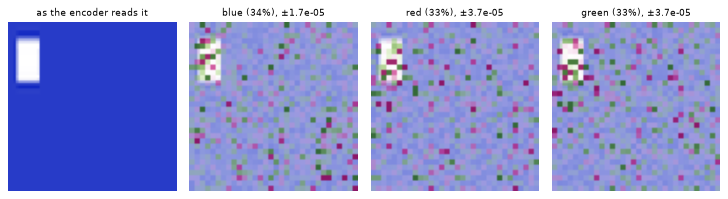

In [ ]:
ia

A protein is a side stream: ESM reads its residues, and the head scores each option against the protein's pooled vector. Its line runs through ESM's embeddings, from every residue masked to the protein:

In [ ]:
from sysone.protein import decision_learner as prot_learner, load_protst

In [ ]:
LOCS = {"nucleus": "SUBCELLULAR LOCATION: Nucleus.", "cytoplasm": "SUBCELLULAR LOCATION: Cytoplasm.", "membrane": "SUBCELLULAR LOCATION: Cell membrane."}
PQ = {"location": {"type": "choice", "instructions": "Where in the cell is this protein found?", "criteria": LOCS}}
AA, rng = "ACDEFGHIKLMNPQRSTVWY", np.random.default_rng(0)
def fixture_protein(i):
    c = i % 3
    seq = "M" + "".join(rng.choice(list(AA[5 * c:5 * c + 5] if rng.random() < 0.5 else AA)) for _ in range(rng.integers(30, 60)))
    return {"id": f"p{i}", "state": {"sequence": seq}, "questions": PQ, "gold": {"location": list(LOCS)[c]}}
precs = [fixture_protein(i) for i in range(30)]
pdata = TypedDecisions.from_records(precs, valid=0.25, calib=0.25, seed=0)
torch.manual_seed(0)
pl = prot_learner(pdata, load_protst("fixtures/tiny-protst"), preset="cpu", loss="soft_ce", cache_dir=tempfile.mkdtemp(), calibrate_after_fit=False)
pl.fit(3, lr=3e-3)
pa = pl.explain(precs[1]["state"], PQ, gold=precs[1]["gold"]["location"], n_steps=64)
test_eq(set(pa.parts), {"stream:protein"})                                                  # the state is the protein alone
test_eq(len(pa.parts["stream:protein"].units), len(precs[1]["state"]["sequence"]) + 2)        # the residues, between <cls> and <eos>
test_eq(pl.model.encoder.sides["protein"].dedupe, True)                                     # back on once the attribution is done
pa.by_segment().round(3)

,stream:protein
nucleus,1.0
cytoplasm,1.0
membrane,1.0


option,p,Δ,Σ,
nucleus,0.63,+4.01,+3.98,
cytoplasm ✓,0.36,-2.87,-2.92,
membrane,0.00,-5.73,-5.65,

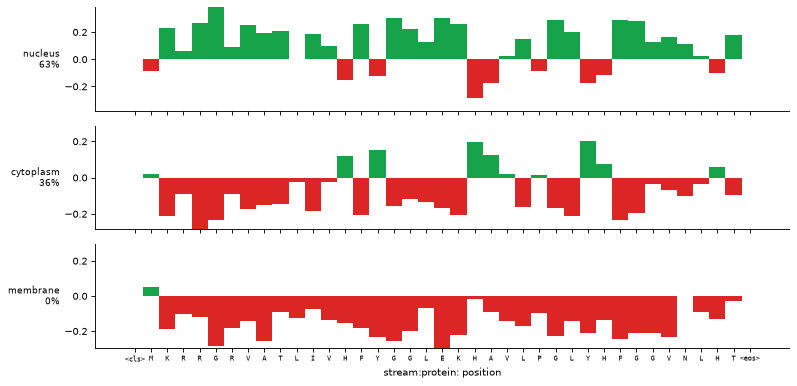

In [ ]:
pa

### Occlusion

Occlusion asks the backend itself. It hides one piece of the state, asks again, and records how far each option's log-odds fall, $f_j(x) - f_j(x_{\setminus u})$, for every piece $u$:

- `kind="words"` removes a window of words from a text;
- `kind="residues"` replaces a window of residues with `X`, the unknown residue, so the rest keep their positions;
- `kind="patches"` paints a square of the image black, or another `fill`.

Windows overlap with `stride`, and a unit's score is the mean over the windows that hid it. It needs only `predict_batch` (or `predict`), so it explains any backend, and it can't drift from the model, since every number is one of the model's own answers. A backend that rounds its probabilities, as a `Decider` does to four decimals, is asked unrounded while occlusion runs, since a probability rounded to 0 has no logarithm. It costs one answer per window. By default it explains the answer and the gold, since the options the model already rules out are mostly noise. `key` names the part of a structured state to occlude, and is found by itself for an `image`, a `sequence` or a `text`.

In [ ]:
#| export
def occlusion(model, state, questions:dict, qid=None, key=None, kind:str|None=None, window:int|None=None, stride:int|None=None, fill=None,
              options=None, target:str="logodds", batch_size:int=16, gold=None) -> Attribution:
    "Attributions through any backend: hide a piece of the state at a time (words, a window of residues, a patch of the image) and measure how far each option's log-odds fall"
    qs = as_questions(questions)
    if qid is None:
        if len(qs) != 1: raise ValueError(f"name the question to explain with qid= ({list(qs)})")
        qid = next(iter(qs))
    q, questions = qs[qid], {qid: questions[qid]}
    st = load_record({"state": state, "questions": questions})["state"]
    if key is None and isinstance(st, dict):
        key = next((k for k in ("image", "sequence", "text") if st.get(k) not in (None, "")), None)
        if key is None: raise ValueError(f"name the part of the state to occlude with key= ({list(st)})")
        if key == "sequence" and kind is None: kind = "residues"
    value = st if key is None else st[key]
    kind = kind or ("patches" if _image_like(value) else "words")
    put = (lambda v: v) if key is None else (lambda v: {**st, key: v})
    if kind == "words":
        if not isinstance(value, str): raise ValueError(f"words are occluded in a text; the state's {key or 'value'} is a {type(value).__name__}")
        spans = [(m.start(), m.end()) for m in re.finditer(r"\S+", value)]
        if not spans: raise ValueError("the text to occlude has no words")
        window, stride = window or 1, stride or 1
        cover = [(i, min(i + window, len(spans))) for i in range(0, max(1, len(spans) - window + 1), stride)]
        variants = [put((value[:spans[a][0]] + value[spans[b - 1][1]:].lstrip(" ")).strip()) for a, b in cover]
        n = len(spans)
    elif kind == "residues":
        window, stride, fill = window or 10, stride or max(1, (window or 10) // 2), fill or "X"
        starts = list(range(0, max(1, len(value) - window + 1), stride))
        if starts[-1] + window < len(value): starts.append(len(value) - window)
        cover = [(a, min(a + window, len(value))) for a in starts]
        variants, n = [put(value[:a] + fill * (b - a) + value[b:]) for a, b in cover], len(value)
    elif kind == "patches":
        from PIL import ImageDraw
        img = load_image(value); W, H = img.size
        window = window or max(1, max(W, H) // 8); stride = stride or max(1, window // 2)
        color = {"black": (0, 0, 0), "gray": (128, 128, 128), "white": (255, 255, 255)}.get(fill or "black", fill)
        xs, ys = list(range(0, max(1, W - window + 1), stride)), list(range(0, max(1, H - window + 1), stride))
        if xs[-1] + window < W: xs.append(W - window)
        if ys[-1] + window < H: ys.append(H - window)
        cover, variants = [(x, y) for y in ys for x in xs], []
        for x, y in cover:
            im = img.copy(); ImageDraw.Draw(im).rectangle([x, y, x + window - 1, y + window - 1], fill=color); variants.append(put(im))
    else: raise ValueError(f"kind must be 'words', 'residues' or 'patches', not {kind!r}")
    f = {"logodds": lambda p: np.log(np.clip(p, 1e-300, 1)) - np.log(np.clip(1 - p, 1e-300, 1)), "logprob": lambda p: np.log(np.clip(p, 1e-300, 1)),
         "prob": lambda p: p}.get(target)
    if f is None: raise ValueError(f"occlusion's target must be 'logodds', 'logprob' or 'prob', not {target!r}")
    digits = getattr(model, "digits", None)
    if digits is not None: model.digits = None          # unrounded: a probability rounded to 0 has no logarithm
    try:
        p0 = np.asarray(answer_probs(q, _predict_many(model, [st], questions, batch_size)[0][qid]), dtype=np.float64)
        answers = _predict_many(model, variants, questions, batch_size)
    finally:
        if digits is not None: model.digits = digits
    g = q.target(gold)[1] if gold is not None else -1
    if options is None: options = list(dict.fromkeys([int(np.argmax(p0))] + ([g] if g >= 0 else [])))
    options = [q.keys.index(o) if o in q.keys else int(o) for o in options]
    drops = np.stack([f(p0)[options] - f(np.asarray(answer_probs(q, a[qid]), dtype=np.float64))[options] for a in answers])
    if kind == "patches":
        S, C = np.zeros((len(options), H, W)), np.zeros((H, W))
        for (x, y), d in zip(cover, drops): S[:, y:y + window, x:x + window] += d[:, None, None]; C[y:y + window, x:x + window] += 1
        part = ImagePart([np.asarray(img, dtype=np.float32) / 255], [S / np.maximum(C, 1)], name=key or "image")
    else:
        S, C = np.zeros((len(options), n)), np.zeros(n)
        for (a, b), d in zip(cover, drops): S[:, a:b] += d[:, None]; C[a:b] += 1
        S = S / np.maximum(C, 1)
        part = TokenPart([(" " if i else "") + value[s:e] for i, (s, e) in enumerate(spans)], ["state"] * n, S, name="words") if kind == "words" \
               else SequencePart(list(value), S, name=key or "sequence")
    return Attribution(q, p0, options, {part.name: part}, "occlusion", target, gold=g, f_input=f(p0)[options], record={"state": st, "questions": questions})

In [ ]:
ow = occlusion(learn.decider(), "the customer asked for a refund and is angry about the delay", {"action": recs[0]["questions"]["action"]})
test_eq((ow.method, len(ow.parts["words"].texts), ow.parts["words"].scores.shape), ("occlusion", 12, (1, 12)))
op = occlusion(ml.decider(), crecs[5]["state"], cq, gold="blue", window=8, stride=4)
test_eq(op.parts["image"].scores[0].shape[1:], PILImage.open(crecs[5]["state"]["image"]).size[::-1])
os_ = occlusion(pl.decider(), precs[1]["state"], PQ, window=6)
test_eq((type(os_.parts["sequence"]).__name__, len(os_.parts["sequence"].units)), ("SequencePart", len(precs[1]["state"]["sequence"])))
ow

option,p,scale,words
human_review,0.25,2.7e-05,the customer asked for a refund and is angry about the delay


option,p,
blue ✓,0.34,

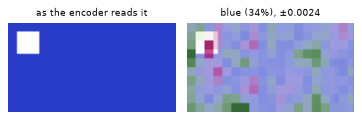

In [ ]:
op

`interp.explain(i)` explains decision `i` of an interpretation, with its record's gold. Through a sysone model it uses `attribute`, and through any other backend only occlusion:

In [ ]:
#| export
@patch
def explain(self:Interpretation, i:int, method:str="ig", **kw) -> Attribution:
    "The attribution of decision `i`: through the model when the backend is a sysone one, by occlusion otherwise"
    (rec, qid), = self.items([i])
    if method != "occlusion" and not hasattr(self.decider, "model"):
        raise ValueError("gradient attributions need a sysone model; use method='occlusion' with this backend")
    return self.decider.explain(rec["state"], rec["questions"], qid, method=method, gold=(rec.get("gold") or {}).get(qid), **kw)

In [ ]:
e = interp.explain(int(interp.top_losses(1)[1][0]))
test_eq(e.gold >= 0, True)
e

Attribution(ig of log-odds · severity: answer '0' · options ['0', '4', '3', '1', '2'] · tokens: 298 tokens)

## How far to trust an attribution

An attribution is a model of the model, and each method can mislead in its own way. Three checks catch most of it, and the [tutorial](tutorials/interpretation.ipynb) runs them on real models.

- **Completeness.** Integrated gradients' attributions must add up to the change of the output from the baseline. The table shows both, Δ and Σ, and marks a row with ⚠ when they are further apart than 0.1 + 10% of the change. Then the integral is wrong, and more steps should close the gap. When more steps don't, the model's output is not smooth along the line, and the attributions are not to be trusted.
- **Agreement.** Occlusion measures something else, the model's actual answer without a piece. When integrated gradients and occlusion rank the same words or patches first, both are probably right.
- **Sanity.** An attribution should change when the model changes. A map that looks the same for a trained head and a random one is showing the input, not the model ([Adebayo et al., 2018](https://arxiv.org/abs/1810.03292)).

`attribution_path` shows the line itself: an option's log-odds at points from the baseline (α = 0) to the input (α = 1). Integrated gradients integrates the slope of this curve, so a smooth curve is one it can integrate, and a jagged one is a warning. On the fixture's little model, the curve is smooth, and the 32 steps are plenty:

::: {.callout-note title="Finding: integrated gradients' attributions didn't add up on the real encoders"}
Integrated gradients is exact only if its integral is computed well, and on the real encoders it often wasn't.

- **Text, frozen.** With the text application's default, ModernBERT-large frozen under the anchor head and trained on 900 tweets, the attributions of an option's log-probability (the target then) missed its change by up to several nats with 32, 64 or 128 steps, from a `[PAD]`, `[MASK]` or `[UNK]` baseline. Along the line, the log-probability moved by up to 1.3 between points 1/200 apart, and zoomed in, by 0.7 within 6 · 10⁻⁵: continuous but jagged. CPU and MPS traced the same curve, so this is the model and not the arithmetic. Even 2,049 exact gradients, summed with the trapezoid rule, missed by up to 3.6, with a sign that changed as the grid got finer.
- **Text, with LoRA.** In the [tutorial](tutorials/interpretation.ipynb#how-far-to-trust-them), the line is smooth but steep, and the answer's attributions stay within 0.35 of a change of 6.53 from 16 steps to 256. Other options miss by a fifth to a quarter.
- **Pixels.** Through ModernVBERT's vision tower, from a black image, the sums missed by a sixth to more than the whole change, some with the wrong sign (−12.69 against +3.55).
- **Residues.** Through ESM-1b from `<mask>`, the attributions of 12 confident proteins in each of four compartments missed their changes by a median of 36% to 57% (the log-probability as the target). Zero vectors, which is what ESM's token dropout feeds the encoder for a masked residue, did no better.

So an `Attribution` reports the change and the sum side by side, and marks the options where they disagree. There, read the attributions as rough at best, and ask occlusion, which needs no integral.
:::

::: {.callout-note title="Finding: a protein's attribution held 20 GB"}
The first protein attribution ran eight integrated-gradient steps per batch through ESM-1b, a 650-million-parameter encoder of 33 layers, over a protein of 395 residues. A backward pass keeps every layer's activations for each step, and with eight steps the process grew to 20 GB on an 18 GB laptop, where it thrashed swap until it was stopped. One step per batch held 5.6 GB, and took 28 s for two options. `attribute` now measures the memory one step keeps for its backward pass before it runs, from the tensors autograd saves, and fits as many steps per batch as `memory`, 2 GB by default, holds. A tweet gets 30 steps per batch, and a protein of 400 to 500 residues one or two even with 4 GB. A larger budget pays where the memory is there: a digit's attribution through ModernVBERT took 93 s with 2 GB, a step per batch, and 12 s with 6 GB, four steps per batch.
:::

In [ ]:
#| export
def attribution_path(model, builder:RowBuilder, state, questions:dict, qid=None, option=None, inputs=None, steps:int=200, baseline="pad",
                     temperatures:dict|None=None, target:str="logodds", lo:float=0.0, hi:float=1.0) -> tuple:
    "The points α from `lo` to `hi` and an option's log-odds (or `target`) there, on the line integrated gradients integrates over: baseline at α = 0, input at α = 1"
    rec, q, row, lines, T, pad = _setup(model, builder, state, questions, qid, inputs, baseline, temperatures)
    alphas, out = np.linspace(lo, hi, steps), []
    with gradients_through(model), torch.no_grad():
        if option is None: o = int(_forward(model, row, pad, lines, [1.0], False, T, "logit")[0][0, :q.k].argmax())    # the answer
        else: o = q.keys.index(option) if option in q.keys else int(option)
        for s in range(0, steps, 16): out.append(_forward(model, row, pad, lines, alphas[s:s + 16], False, T, target)[0][:, o].cpu().numpy())
    return alphas, np.concatenate(out)

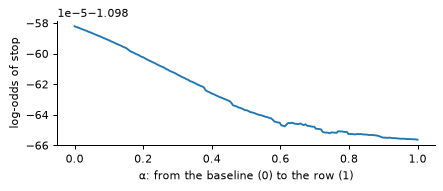

In [ ]:
al, fl = attribution_path(learn.model, learn.data.builder, recs[0]["state"], recs[0]["questions"], "action", option="stop")
ga = learn.explain(recs[0]["state"], recs[0]["questions"], "action", options=["stop"])
test_eq((len(al), len(fl)), (200, 200))
test_close((fl[0], fl[-1]), (ga.f_baseline[0], ga.f_input[0]), eps=1e-4)            # the line runs from the baseline to the row
fig, ax = plt.subplots(figsize=(5, 2.2))
ax.plot(al, fl, lw=1.5); ax.set(xlabel="α: from the baseline (0) to the row (1)", ylabel="log-odds of stop")
plt.tight_layout(); plt.show()